# DR Criterion Study
### ttH(bb) dilepton — mass reco combination selection analysis
Compares max_weight-only selection vs DR-criterion selection across all 4 ranks.

In [30]:
from coffea.util import load
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import hist
import warnings
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
COFFEA_FILE = '/eos/home-i04/p/piosifid/PocketCoffea/ANN_newCoffea/DATA_MassReco/mc_nolumi_more_andmore_andmore/output_all.coffea'
DATASET     = 'TTH_Hto2B'
CATEGORY    = 'baseline_all_atleast4bjets'

out = load(COFFEA_FILE)
print('Top-level keys:', list(out.keys())[:10], '...')
variables = out['variables']
new_vars = [v for v in variables.keys() if any(k in v.lower() for k in 
            ['rank1_correct', 'rank2_correct', 'rank3_correct', 'rank4_correct',
             'rank1_wrong', 'rank2_wrong', 'rank3_wrong', 'rank4_wrong',
             'correct_match_rank', 'maxweight_wrong', 'maxweight_correct_dr', 'maxweight_wrong_dr'])]
print('New A7/A8 variables:')
for v in sorted(new_vars):
    print(' ', v)

out_mc = load(COFFEA_FILE)
variables = out_mc['variables']
new_vars = [v for v in variables.keys() if any(k in v for k in 
            ['selected_correct', 'selected_wrong', 'rejected_correct', 'rejected_wrong'])]
print(f'New A9 variables ({len(new_vars)}):')
for v in sorted(new_vars):
    print(' ', v)

Top-level keys: ['sum_genweights', 'sum_signOf_genweights', 'sumw', 'sumw2', 'cutflow', 'variables', 'columns', 'processing_metadata', 'datasets_metadata'] ...
New A7/A8 variables:
  correct_match_rank1
  correct_match_rank2
  correct_match_rank3
  correct_match_rank4
  higgs_mass_rank1_correct
  higgs_mass_rank1_wrong
  higgs_mass_rank2_correct
  higgs_mass_rank2_wrong
  higgs_mass_rank3_correct
  higgs_mass_rank3_wrong
  higgs_mass_rank4_correct
  higgs_mass_rank4_wrong
  massreco_maxweight_correct_dr
  massreco_maxweight_wrong_dr
  massreco_maxweight_wrong_higgs_mass
New A9 variables (26):
  higgs_mass_fallback_selected_correct
  higgs_mass_fallback_selected_wrong
  higgs_mass_rank1_rejected_correct
  higgs_mass_rank1_rejected_wrong
  higgs_mass_rank1_selected_correct
  higgs_mass_rank1_selected_wrong
  higgs_mass_rank2_rejected_correct
  higgs_mass_rank2_rejected_wrong
  higgs_mass_rank2_selected_correct
  higgs_mass_rank2_selected_wrong
  higgs_mass_rank3_rejected_correct
  higgs_

In [31]:
# ── helper: extract 1D histogram values and bin centres ──────────────────
def get_hist(out, var, dataset=DATASET, category=CATEGORY):
    """
    Return (values, edges) for a 1D histogram.
    Handles PocketCoffea nesting:
        variables[var][dataset][variation] -> Hist with axes 'cat' and/or 'variation'
    """
    from hist import Hist
    variables = out['variables']
    if var not in variables:
        raise KeyError(f"'{var}' not in variables.")
    hist_container = variables[var]
    if dataset not in hist_container:
        raise KeyError(f"Dataset '{dataset}' not found. Available: {list(hist_container.keys())}")
    # iterate over variations, pick the first Hist object
    h = None
    for variation, obj in hist_container[dataset].items():
        if isinstance(obj, Hist):
            h = obj
            break
    if h is None:
        raise ValueError(f'No Hist object found for {var}/{dataset}')
    # slice cat axis if present
    ax_names = [ax.name for ax in h.axes]
    if 'cat' in ax_names:
        h = h[{'cat': category}]
    # slice variation axis if present
    ax_names = [ax.name for ax in h.axes]
    if 'variation' in ax_names:
        h = h[{'variation': 'nominal'}]
    vals  = h.values()
    edges = h.axes[0].edges
    return vals, edges

def get_hist2d(out, var, dataset=DATASET, category=CATEGORY):
    from hist import Hist
    variables = out['variables']
    if var not in variables:
        raise KeyError(f"'{var}' not in variables.")
    h = None
    for variation, obj in variables[var][dataset].items():
        if isinstance(obj, Hist):
            h = obj
            break
    ax_names = [ax.name for ax in h.axes]
    if 'cat' in ax_names:
        h = h[{'cat': category}]
    if 'variation' in ax_names:
        h = h[{'variation': 'nominal'}]
    return h.values(), h.axes[0].edges, h.axes[1].edges


def centres(edges):
    return 0.5 * (edges[:-1] + edges[1:])

def integral(vals, edges):
    widths = np.diff(edges)
    return np.sum(vals * widths)

# ── style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        12,
})

COLORS = {
    'rank1': '#2166ac',
    'rank2': '#f4a582',
    'rank3': '#d6604d',
    'rank4': '#92c5de',
    'maxweight': '#2166ac',
    'dr':        '#d6604d',
    'truth':     '#4dac26',
}

print('Helpers loaded.')

Helpers loaded.


## Step 1 — Check available histograms

In [32]:
# Print all histogram names to verify what's in the file
all_vars = list(out.keys())
dr_vars  = [v for v in all_vars if any(k in v.lower() for k in
             ['rank', 'dr_', 'correct_match', 'maxweight', 'chosen', 'truth', 'pair_in', 'mass_reco_had'])]
print('DR-study related histograms found:')
for v in sorted(dr_vars):
    print(' ', v)

DR-study related histograms found:


## Group 1 — DR Criterion Activity
### Plot 1.1 — How often does each rank get used?

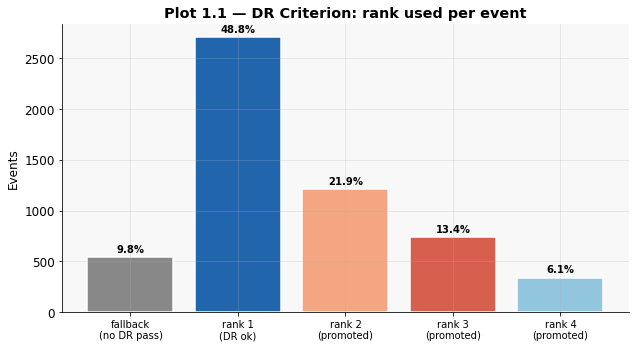

In [8]:
vals, edges = get_hist(out, 'rank_used')

# Skip bin 0 (no reco = None, always 0)
vals_plot   = vals[1:]
rank_labels = ['fallback\n(no DR pass)', 'rank 1\n(DR ok)',
               'rank 2\n(promoted)', 'rank 3\n(promoted)', 'rank 4\n(promoted)']
bar_colors  = ['#888888', COLORS['rank1'], COLORS['rank2'], COLORS['rank3'], COLORS['rank4']]

fig, ax = plt.subplots(figsize=(9, 5))
bars  = ax.bar(range(len(vals_plot)), vals_plot, color=bar_colors, edgecolor='white', linewidth=1.5)
total = vals_plot.sum()
for bar, v in zip(bars, vals_plot):
    pct = 100 * v / max(1, total)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(vals_plot)))
ax.set_xticklabels(rank_labels, fontsize=10)
ax.set_ylabel('Events')
ax.set_title('Plot 1.1 — DR Criterion: rank used per event', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_1_1_rank_used.png', dpi=150)
plt.show()

## Group 2 — Kinematics per rank
### Plot 2.1 — Higgs mass distributions per rank

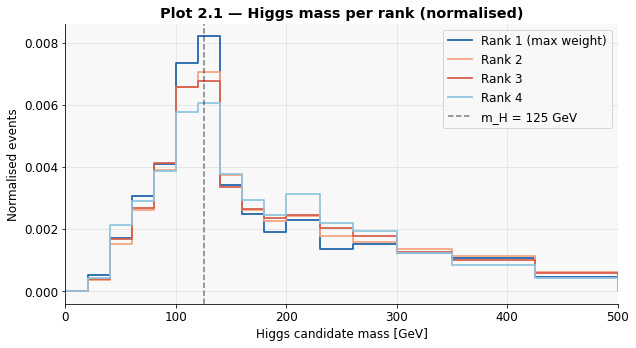

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for rank, color, label in [
    ('higgs_mass_rank1', COLORS['rank1'], 'Rank 1 (max weight)'),
    ('higgs_mass_rank2', COLORS['rank2'], 'Rank 2'),
    ('higgs_mass_rank3', COLORS['rank3'], 'Rank 3'),
    ('higgs_mass_rank4', COLORS['rank4'], 'Rank 4'),
]:
    try:
        v, e = get_hist(out, rank)
        norm = integral(v, e)
       # ax.step(np.append(e[:-1], e[-1]), np.append(v, 0),
       # where='post', color=color, label=label, linewidth=1.8)
        ax.step(np.append(e[:-1], e[-1]), np.append(v / max(1, norm), 0),
        where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {rank}: {ex}')

ax.axvline(125, color='black', linestyle='--', alpha=0.5, label='m_H = 125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 500)
ax.legend()
ax.set_title('Plot 2.1 — Higgs mass per rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_2_1_higgs_mass_per_rank.png', dpi=150)
plt.show()

### Plot 2.2 — DR distributions per rank

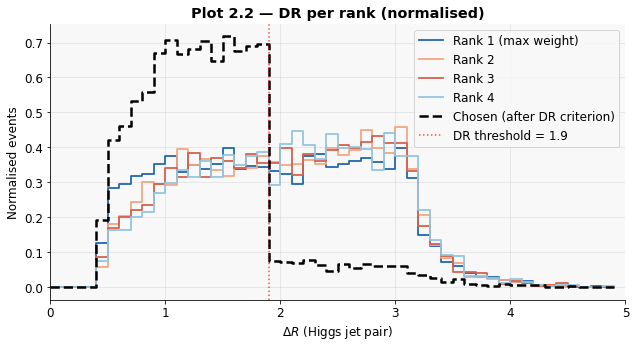

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for rank, color, label in [
    ('dr_rank1', COLORS['rank1'], 'Rank 1 (max weight)'),
    ('dr_rank2', COLORS['rank2'], 'Rank 2'),
    ('dr_rank3', COLORS['rank3'], 'Rank 3'),
    ('dr_rank4', COLORS['rank4'], 'Rank 4'),
    ('dr_chosen', 'black',        'Chosen (after DR criterion)'),
]:
    try:
        v, e = get_hist(out, rank)
        norm = integral(v, e)
        ls = '-' if rank != 'dr_chosen' else '--'
        lw = 1.8 if rank != 'dr_chosen' else 2.5
        ax.step(e[:-1], v / max(1, norm), where='post', color=color,
                label=label, linewidth=lw, linestyle=ls)
    except Exception as ex:
        print(f'  Skipping {rank}: {ex}')

ax.axvline(1.9, color='red', linestyle=':', alpha=0.7, label='DR threshold = 1.9')
ax.set_xlabel(r'$\Delta R$ (Higgs jet pair)')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 5)
ax.legend()
ax.set_title('Plot 2.2 — DR per rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_2_2_dr_per_rank.png', dpi=150)
plt.show()

## Group 3 — Truth matching per rank
### Plot 3.1 — correct_match distribution: max_weight vs DR criterion

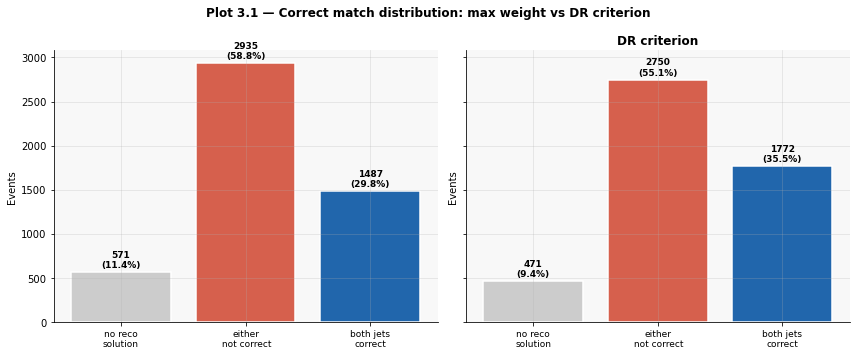

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
match_labels = ['no reco\nsolution', 'either\n not correct', 'both jets\ncorrect']
match_colors = ['#cccccc', '#d6604d', '#2166ac']

for ax, var, title in [
    (axes[0], 'correct_match_maxweight', ''),
    (axes[1], 'correct_match_dr',        'DR criterion'),
]:
    try:
        v, e = get_hist(out_mc, var)
        v = v[:3]  # drop empty 4th bin
        total = v.sum()
        bars = ax.bar(range(3), v, color=match_colors,
                      edgecolor='white', linewidth=1.5)
        for bar, val in zip(bars, v):
            pct = 100 * val / max(1, total)
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                    f'{val:.0f}\n({pct:.1f}%)', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
        ax.set_xticks(range(3))
        ax.set_xticklabels(match_labels, fontsize=9)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Events')
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')

fig.suptitle('Plot 3.1 — Correct match distribution: max weight vs DR criterion', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_3_1_correct_match_comparison.png', dpi=150)
plt.show()

### Plot 3.2 — Promotion category breakdown
Derived from `rank_used`, `correct_match_maxweight`, `correct_match_dr`

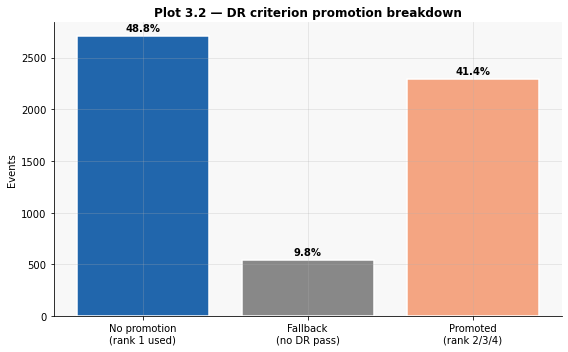

In [18]:
# We approximate promotion categories from the histograms
# rank_used==1 → no promotion; rank_used in {2,3,4,0} → promoted
# For promoted events, we use correct_match_maxweight vs correct_match_dr

try:
    v_rank,  e_rank  = get_hist(out, 'rank_used')
    v_mw,    e_mw    = get_hist(out, 'correct_match_maxweight')
    v_dr,    e_dr    = get_hist(out, 'correct_match_dr')

    # rank_used bins: [-1,0,1,2,3,4,5] → no_reco, fallback, rank1, rank2, rank3, rank4
    n_no_reco    = v_rank[0]  # rank=None stored as -1
    n_fallback   = v_rank[1]  # rank=0
    n_rank1      = v_rank[2]  # rank=1
    n_promoted   = v_rank[3] + v_rank[4] + v_rank[5]  # ranks 2,3,4

    # correct_match bins: 0=no reco, 1=neither, 2=one, 3=both (approximately)
    n_mw_correct = v_mw[-1] if len(v_mw) >= 3 else 0  # both correct
    n_dr_correct = v_dr[-1] if len(v_dr) >= 3 else 0

    categories = [
        ('No promotion\n(rank 1 used)',   n_rank1,    '#2166ac'),
        ('Fallback\n(no DR pass)',         n_fallback, '#888888'),
        ('Promoted\n(rank 2/3/4)',         n_promoted, '#f4a582'),
    ]

    fig, ax = plt.subplots(figsize=(8, 5))
    labels, counts, colors = zip(*categories)
    bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
    total = sum(counts)
    for bar, v in zip(bars, counts):
        pct = 100 * v / max(1, total)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Events')
    ax.set_title('Plot 3.2 — DR criterion promotion breakdown', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_3_2_promotion_breakdown.png', dpi=150)
    plt.show()

except Exception as ex:
    print(f'Could not make plot 3.2: {ex}')

### Plot 3.3 — Higgs mass: correct vs wrong, for max_weight and DR criterion

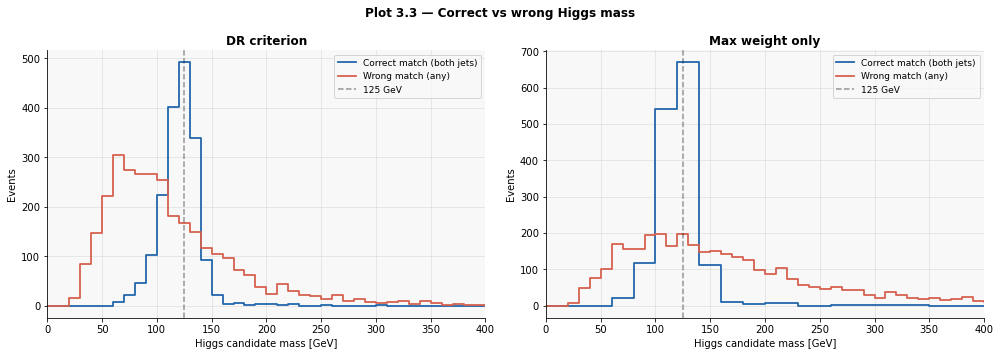

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, correct_var, wrong_var, title in [
    (axes[0],
     'Massreco_chosen_pair_correct_higgs_mass',
     'Massreco_chosen_pair_wrong_higgs_mass',
     'DR criterion'),
    (axes[1],
     'higgs_mass_rank1_correct',
     'massreco_maxweight_wrong_higgs_mass',
     'Max weight only'),
]:
    for var, color, label in [
        (correct_var, COLORS['rank1'], 'Correct match (both jets)'),
        (wrong_var,   COLORS['rank3'], 'Wrong match (any)'),
    ]:
        try:
            v, e = get_hist(out_mc, var)
            ax.step(np.append(e[:-1], e[-1]), np.append(v, 0),
                    where='post', color=color, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
    ax.set_xlabel('Higgs candidate mass [GeV]')
    ax.set_ylabel('Events')
    ax.set_xlim(0, 400)
    ax.legend(fontsize=9)
    ax.set_title(title, fontweight='bold')

fig.suptitle('Plot 3.3 — Correct vs wrong Higgs mass', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_3_3_correct_vs_wrong_mass.png', dpi=150)
plt.show()

## Group 4 — Bottom line comparison
### Plot 4.1 — Overall Higgs mass: max_weight vs DR criterion

  Skipping massreco_chosen_pair_all_higgs_mass: "'massreco_chosen_pair_all_higgs_mass' not in variables."


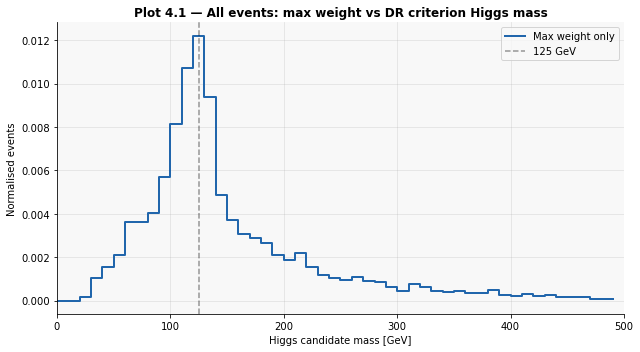

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

for var, color, label in [
    ('massreco_maxweight_higgs_mass', COLORS['maxweight'], 'Max weight only'),
    ('massreco_chosen_pair_all_higgs_mass',             COLORS['dr'],        'DR criterion'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')

ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 500)
ax.legend()
ax.set_title('Plot 4.1 — All events: max weight vs DR criterion Higgs mass', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4_1_overall_mass_comparison.png', dpi=150)
plt.show()

### Plot 4.2 — Correct match Higgs mass & Plot 4.2b — Wrong match Higgs mass

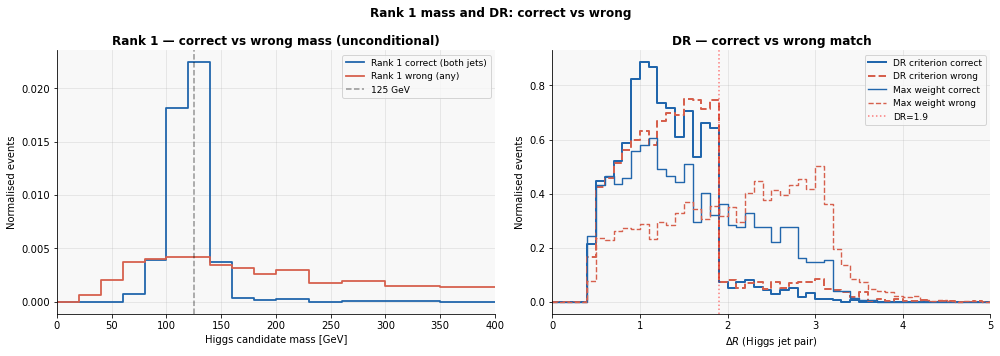

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: correct vs wrong mass for rank 1
ax = axes[0]
for var, color, label in [
    ('higgs_mass_rank1_correct', COLORS['rank1'], 'Rank 1 correct (both jets)'),
    ('higgs_mass_rank1_wrong',   COLORS['rank3'], 'Rank 1 wrong (any)'),
]:
    v, e = get_hist(out_mc, var)
    norm = integral(v, e)
    ax.step(np.append(e[:-1], e[-1]), np.append(v / max(1, norm), 0),
            where='post', color=color, label=label, linewidth=1.8)
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Rank 1 — correct vs wrong mass (unconditional)', fontweight='bold')

# Right: DR distribution for correct vs wrong rank 1
ax = axes[1]
for var, color, label in [
    ('Massreco_chosen_pair_correct_dr', COLORS['rank1'], 'DR criterion correct'),
    ('Massreco_chosen_pair_wrong_dr',   COLORS['rank3'], 'DR criterion wrong'),
    ('massreco_maxweight_correct_dr',   COLORS['rank1'], 'Max weight correct'),
    ('massreco_maxweight_wrong_dr',     COLORS['rank3'], 'Max weight wrong'),
]:
    try:
        v, e = get_hist(out_mc, var)
        norm = integral(v, e)
        ls = '-' if 'correct' in var else '--'
        lw = 2.0 if 'chosen' in var or 'chosen' in var else 1.4
        ax.step(np.append(e[:-1], e[-1]), np.append(v / max(1, norm), 0),
                where='post', color=color, linestyle=ls, label=label, linewidth=lw)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(1.9, color='red', linestyle=':', alpha=0.5, label='DR=1.9')
ax.set_xlabel(r'$\Delta R$ (Higgs jet pair)')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 5)
ax.legend(fontsize=9)
ax.set_title('DR — correct vs wrong match', fontweight='bold')

plt.suptitle('Rank 1 mass and DR: correct vs wrong', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_rank1_correct_wrong_mass_dr.png', dpi=150)
plt.show()

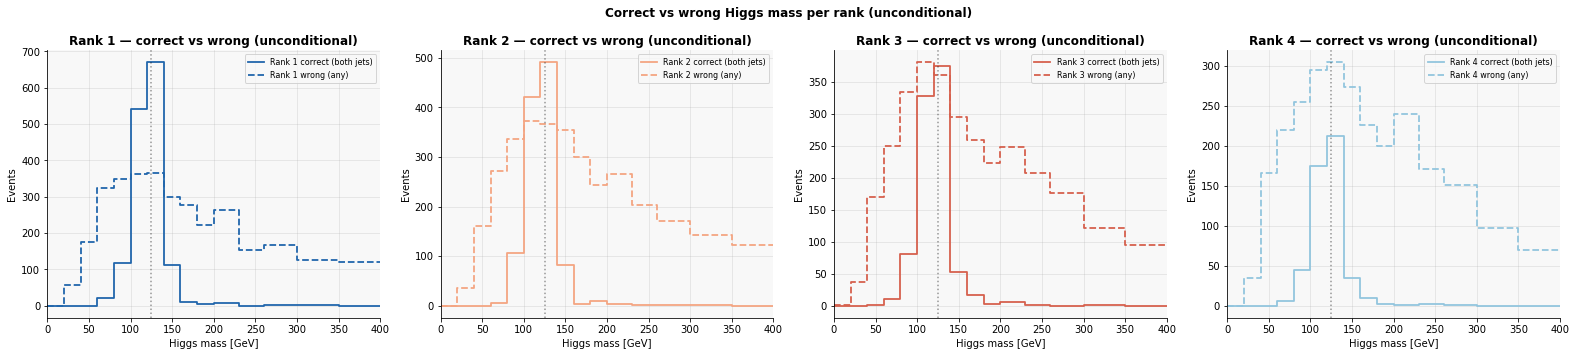

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
rank_colors = [COLORS['rank1'], COLORS['rank2'], COLORS['rank3'], COLORS['rank4']]

for ax, r, color in zip(axes, [1,2,3,4], rank_colors):
    for var, ls, label in [
        (f'higgs_mass_rank{r}_correct', '-',  f'Rank {r} correct (both jets)'),
        (f'higgs_mass_rank{r}_wrong',   '--', f'Rank {r} wrong (any)'),
    ]:
        try:
            v, e = get_hist(out_mc, var)
            norm = integral(v, e)
            ax.step(np.append(e[:-1], e[-1]), np.append(v , 0),
                    where='post', color=color, linestyle=ls, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(125, color='black', linestyle=':', alpha=0.4)
    ax.set_xlabel('Higgs mass [GeV]')
    ax.set_ylabel('Events')
    ax.set_xlim(0, 400)
    ax.legend(fontsize=8)
    ax.set_title(f'Rank {r} — correct vs wrong (unconditional)', fontweight='bold')

plt.suptitle('Correct vs wrong Higgs mass per rank (unconditional)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_rank_correct_wrong_mass.png', dpi=150)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  Skipping massreco_chosen_pair_correct_higgs_mass: "'massreco_chosen_pair_correct_higgs_mass' not in variables."
  Skipping massreco_chosen_pair_wrong_higgs_mass: "'massreco_chosen_pair_wrong_higgs_mass' not in variables."
  Skipping massreco_chosen_pair_wrong_higgs_mass_1_jets: "'massreco_chosen_pair_wrong_higgs_mass_1_jets' not in variables."
  Skipping massreco_chosen_pair_wrong_higgs_mass_2_jets: "'massreco_chosen_pair_wrong_higgs_mass_2_jets' not in variables."


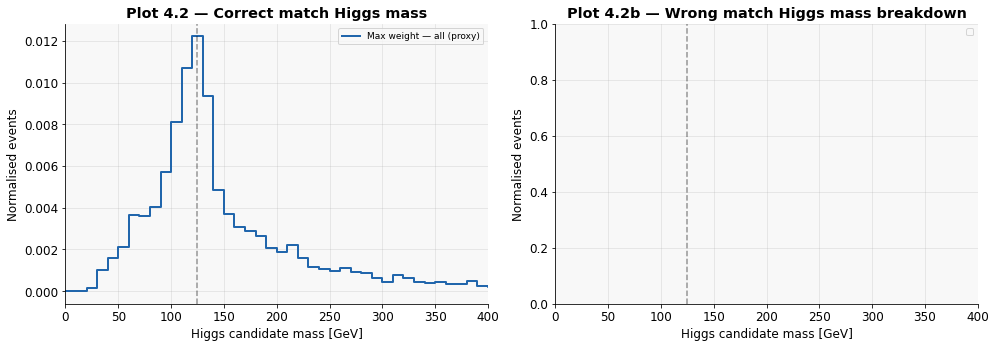

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 4.2 — correct match
ax = axes[0]
for var, color, label in [
    ('massreco_chosen_pair_correct_higgs_mass', COLORS['dr'],        'DR criterion — correct'),
    ('massreco_maxweight_higgs_mass',           COLORS['maxweight'], 'Max weight — all (proxy)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 4.2 — Correct match Higgs mass', fontweight='bold')

# Plot 4.2b — wrong match
ax = axes[1]
for var, color, label in [
    ('massreco_chosen_pair_wrong_higgs_mass',         COLORS['dr'],   'Neither jet correct'),
    ('massreco_chosen_pair_wrong_higgs_mass_1_jets',  '#f4a582',      'One jet correct'),
    ('massreco_chosen_pair_wrong_higgs_mass_2_jets',  '#d6604d',      'Both jets wrong (all)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 4.2b — Wrong match Higgs mass breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_4_2_correct_wrong_mass.png', dpi=150)
plt.show()

### Plot 4.3 — Efficiency: correct_match==2 rate, max_weight vs DR criterion

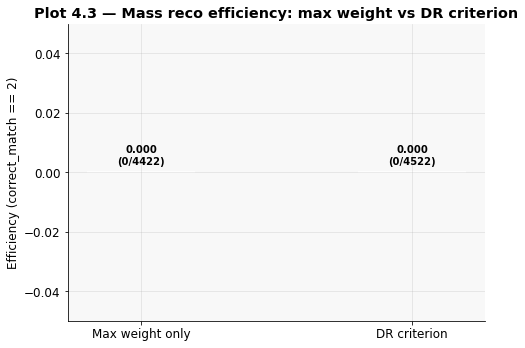


Summary:
  Max weight only: 0.000 (0/4422)
  DR criterion: 0.000 (0/4522)
  Delta (DR - maxweight): +0.000 (+0.0%)


In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

results = {}
for var, label in [
    ('correct_match_maxweight', 'Max weight only'),
    ('correct_match_dr',        'DR criterion'),
]:
    try:
        v, e = get_hist(out, var)
        # bins: 0=no reco, 1=neither, 2=one, 3=both correct
        total_with_reco = v[1:].sum()
        both_correct    = v[-1] if len(v) >= 4 else v[3]
        eff = both_correct / max(1, total_with_reco)
        results[label] = (eff, both_correct, total_with_reco)
    except Exception as ex:
        print(f'  Could not compute efficiency for {var}: {ex}')
        results[label] = (0, 0, 0)

labels = list(results.keys())
effs   = [results[l][0] for l in labels]
colors = [COLORS['maxweight'], COLORS['dr']]

bars = ax.bar(labels, effs, color=colors, edgecolor='white', linewidth=1.5, width=0.4)
for bar, (label, (eff, n_correct, n_total)) in zip(bars, results.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{eff:.3f}\n({int(n_correct)}/{int(n_total)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Efficiency (correct_match == 2)')
ax.set_ylim(0, max(effs) * 1.3)
ax.set_title('Plot 4.3 — Mass reco efficiency: max weight vs DR criterion', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4_3_efficiency_comparison.png', dpi=150)
plt.show()

print('\nSummary:')
for label, (eff, n_correct, n_total) in results.items():
    print(f'  {label}: {eff:.3f} ({int(n_correct)}/{int(n_total)})')
if len(results) == 2:
    effs_list = list(results.values())
    delta = effs_list[1][0] - effs_list[0][0]
    print(f'  Delta (DR - maxweight): {delta:+.3f} ({delta*100:+.1f}%)')

### Plot 4.4 — Truth Higgs mass vs reco Higgs mass
*(Requires 2D histogram — add to config and rerun if not available)*

In [17]:
# Check if 2D histogram is available
try:
    h2d = out['truth_vs_reco_higgs_mass'][DATASET][CATEGORY]
    vals2d = h2d.values()
    ex = h2d.axes[0].edges
    ey = h2d.axes[1].edges

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, var2d, title in [
        (axes[0], 'truth_vs_reco_higgs_mass_maxweight', 'Max weight only'),
        (axes[1], 'truth_vs_reco_higgs_mass',           'DR criterion'),
    ]:
        try:
            h = out[var2d][DATASET][CATEGORY]
            im = ax.pcolormesh(h.axes[0].edges, h.axes[1].edges,
                               h.values().T, cmap='Blues')
            plt.colorbar(im, ax=ax, label='Events')
            ax.plot([0, 500], [0, 500], 'r--', alpha=0.5, label='truth = reco')
            ax.set_xlabel('Truth Higgs mass [GeV]')
            ax.set_ylabel('Reco Higgs mass [GeV]')
            ax.set_title(title, fontweight='bold')
            ax.legend()
        except Exception as ex:
            print(f'  {var2d} not available: {ex}')

    fig.suptitle('Plot 4.4 — Truth vs reco Higgs mass 2D', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_4_4_truth_vs_reco_2d.png', dpi=150)
    plt.show()

except:
    print('Plot 4.4: 2D histogram not in coffea file.')
    print('Add truth_vs_reco_higgs_mass to the config and rerun to enable this plot.')

Plot 4.4: 2D histogram not in coffea file.
Add truth_vs_reco_higgs_mass to the config and rerun to enable this plot.


## Group 5 — Selected vs Rejected per rank
### Plot 5.1 — Higgs mass: selected-from-rank overlaid

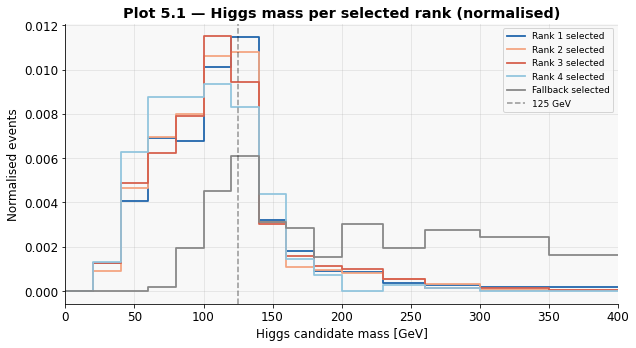

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
for var, color, label in [
    ('higgs_mass_chosen_from_rank1',   COLORS['rank1'], 'Rank 1 selected'),
    ('higgs_mass_chosen_from_rank2',   COLORS['rank2'], 'Rank 2 selected'),
    ('higgs_mass_chosen_from_rank3',   COLORS['rank3'], 'Rank 3 selected'),
    ('higgs_mass_chosen_from_rank4',   COLORS['rank4'], 'Rank 4 selected'),
    ('higgs_mass_chosen_from_fallback','#888888',       'Fallback selected'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 5.1 — Higgs mass per selected rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_5_1_higgs_mass_selected_per_rank.png', dpi=150)
plt.show()

### Plot 5.2 — Higgs mass: rejected-from-rank overlaid

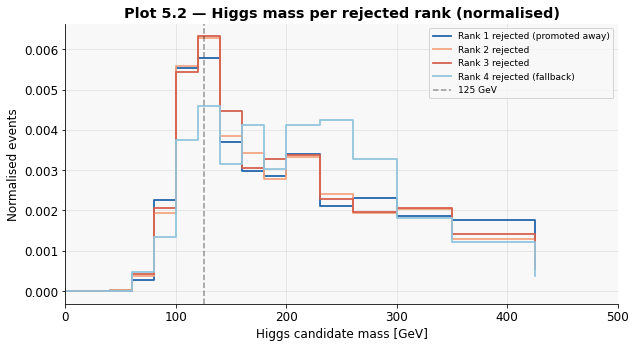

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
for var, color, label in [
    ('higgs_mass_rank1_rejected', COLORS['rank1'], 'Rank 1 rejected (promoted away)'),
    ('higgs_mass_rank2_rejected', COLORS['rank2'], 'Rank 2 rejected'),
    ('higgs_mass_rank3_rejected', COLORS['rank3'], 'Rank 3 rejected'),
    ('higgs_mass_rank4_rejected', COLORS['rank4'], 'Rank 4 rejected (fallback)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 500)
ax.legend(fontsize=9)
ax.set_title('Plot 5.2 — Higgs mass per rejected rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_5_2_higgs_mass_rejected_per_rank.png', dpi=150)
plt.show()

### Plot 5.3 — DR: selected vs rejected per rank (2x4 grid)

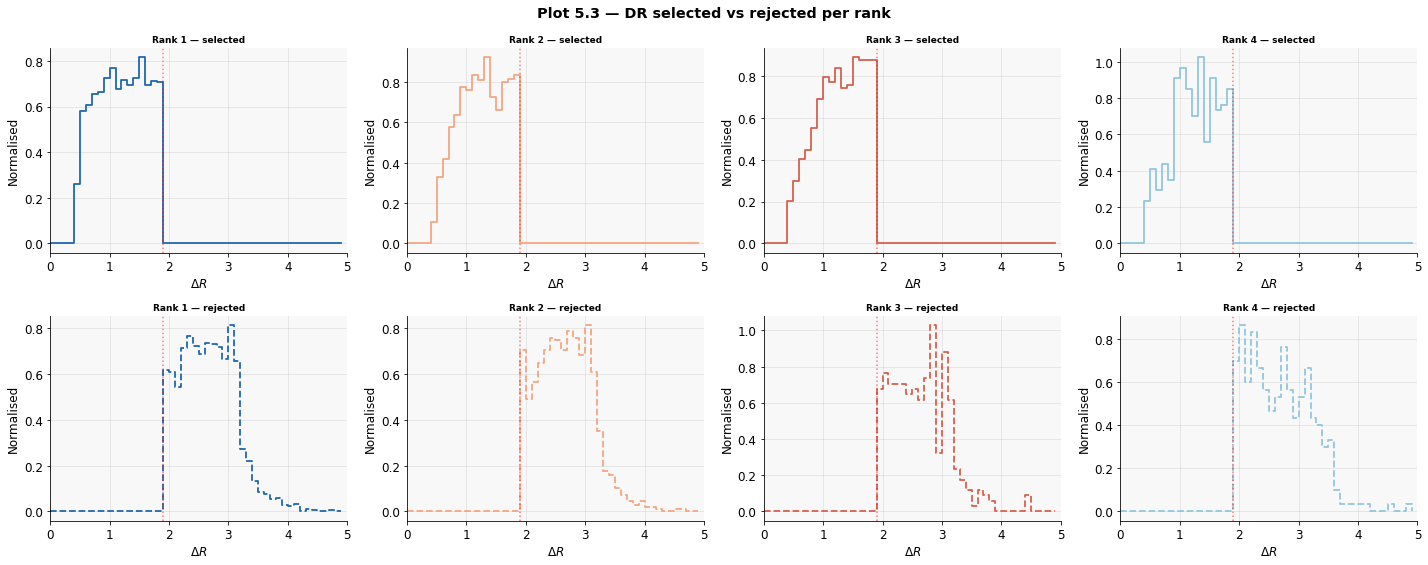

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
ranks = [
    ('dr_chosen_from_rank1',   'dr_rank1_rejected',   COLORS['rank1'], 'Rank 1'),
    ('dr_chosen_from_rank2',   'dr_rank2_rejected',   COLORS['rank2'], 'Rank 2'),
    ('dr_chosen_from_rank3',   'dr_rank3_rejected',   COLORS['rank3'], 'Rank 3'),
    ('dr_chosen_from_rank4',   'dr_rank4_rejected',   COLORS['rank4'], 'Rank 4'),
]
for col, (sel_var, rej_var, color, label) in enumerate(ranks):
    for row, (var, ls, title_sfx) in enumerate([
        (sel_var, '-',  'selected'),
        (rej_var, '--', 'rejected'),
    ]):
        ax = axes[row][col]
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(e[:-1], v / max(1, norm), where='post', color=color, linewidth=1.8, linestyle=ls)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
        ax.axvline(1.9, color='red', linestyle=':', alpha=0.5, label='DR=1.9')
        ax.set_xlabel(r'$\Delta R$')
        ax.set_ylabel('Normalised')
        ax.set_xlim(0, 5)
        ax.set_title(f'{label} — {title_sfx}', fontweight='bold', fontsize=9)
fig.suptitle('Plot 5.3 — DR selected vs rejected per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_5_3_dr_selected_vs_rejected.png', dpi=150)
plt.show()

## Group 6 — 2D histograms
### Plot 6.1 — Mass vs mass rank transitions

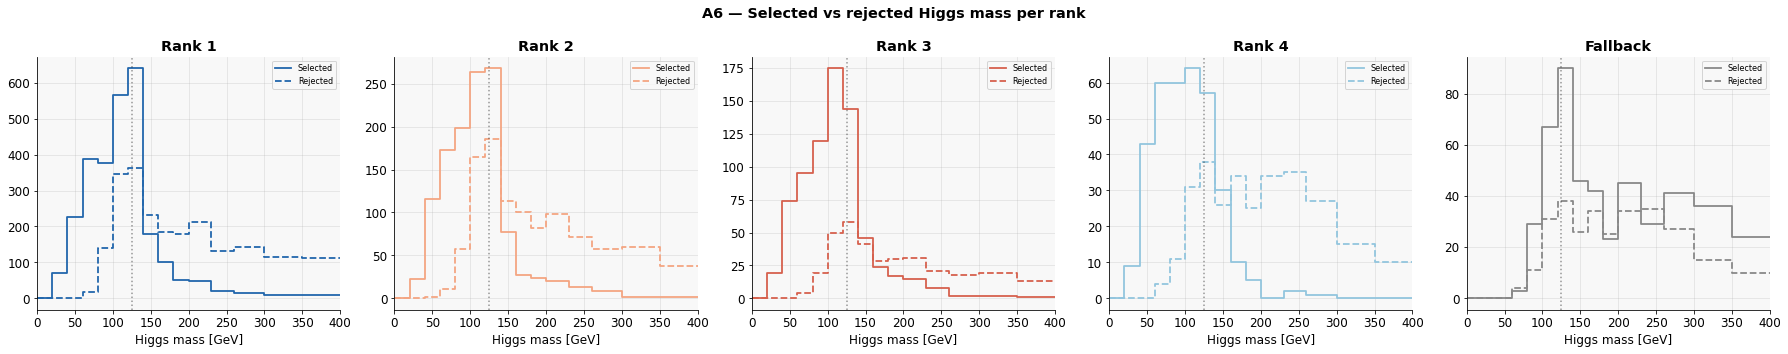

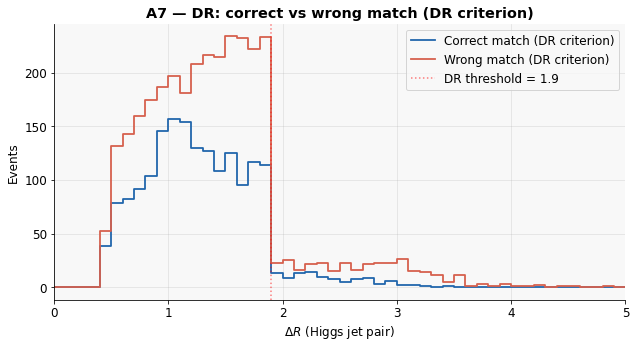

In [21]:
# A6 — Selected vs rejected mass per rank
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
rank_data = [
    ('higgs_mass_chosen_from_rank1',    'higgs_mass_rank1_rejected',   COLORS['rank1'], 'Rank 1'),
    ('higgs_mass_chosen_from_rank2',    'higgs_mass_rank2_rejected',   COLORS['rank2'], 'Rank 2'),
    ('higgs_mass_chosen_from_rank3',    'higgs_mass_rank3_rejected',   COLORS['rank3'], 'Rank 3'),
    ('higgs_mass_chosen_from_rank4',    'higgs_mass_rank4_rejected',   COLORS['rank4'], 'Rank 4'),
    ('higgs_mass_chosen_from_fallback', 'higgs_mass_rank4_rejected',   '#888888',       'Fallback'),
]
for ax, (sel_var, rej_var, color, label) in zip(axes, rank_data):
    for var, ls, lbl in [
        (sel_var, '-',  'Selected'),
        (rej_var, '--', 'Rejected'),
    ]:
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(np.append(e[:-1], e[-1]), np.append(v, 0),
                    where='post', color=color, linestyle=ls, label=lbl, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(125, color='black', linestyle=':', alpha=0.4)
    ax.set_xlabel('Higgs mass [GeV]')
    ax.set_ylabel('')
    ax.set_xlim(0, 400)
    ax.legend(fontsize=8)
    ax.set_title(label, fontweight='bold')
fig.suptitle('A6 — Selected vs rejected Higgs mass per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A6_selected_vs_rejected_mass.png', dpi=150)
plt.show()

# A7 — DR correct vs wrong (DR criterion only for now)
fig, ax = plt.subplots(figsize=(9, 5))
for var, color, label in [
    ('Massreco_chosen_pair_correct_dr', COLORS['rank1'], 'Correct match (DR criterion)'),
    ('Massreco_chosen_pair_wrong_dr',   COLORS['rank3'], 'Wrong match (DR criterion)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(np.append(e[:-1], e[-1]), np.append(v, 0),
                where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(1.9, color='red', linestyle=':', alpha=0.5, label='DR threshold = 1.9')
ax.set_xlabel(r'$\Delta R$ (Higgs jet pair)')
ax.set_ylabel('Events')
ax.set_xlim(0, 5)
ax.legend()
ax.set_title('A7 — DR: correct vs wrong match (DR criterion)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A7_dr_correct_vs_wrong.png', dpi=150)
plt.show()

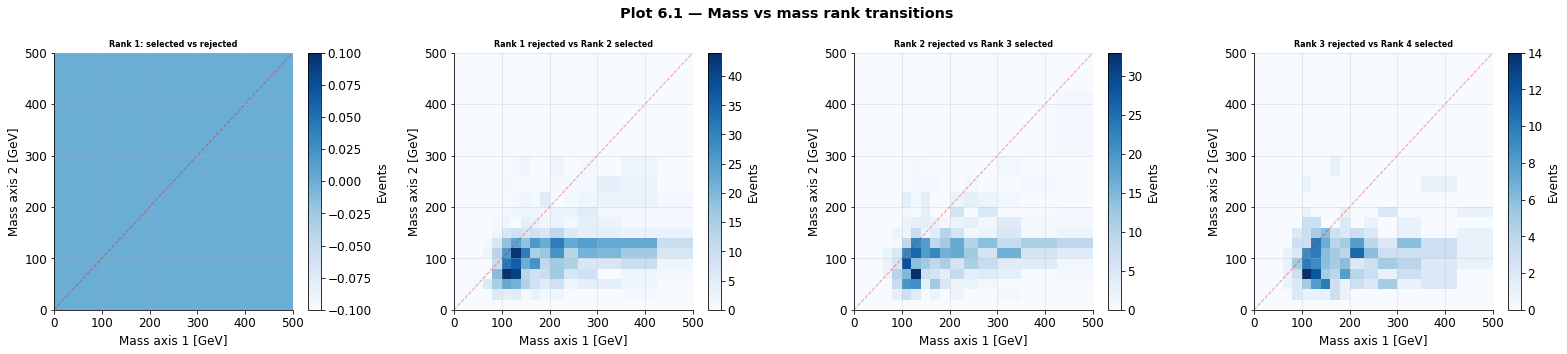

In [22]:
def get_hist2d(out, var, dataset=DATASET, category=CATEGORY):
    from hist import Hist
    variables = out['variables']
    if var not in variables:
        raise KeyError(f"'{var}' not in variables.")
    h = None
    for variation, obj in variables[var][dataset].items():
        if isinstance(obj, Hist):
            h = obj
            break
    ax_names = [ax.name for ax in h.axes]
    if 'cat' in ax_names:
        h = h[{'cat': category}]
    if 'variation' in ax_names:
        h = h[{'variation': 'nominal'}]
    return h.values(), h.axes[0].edges, h.axes[1].edges

transitions = [
    ('higgs_mass_rank1_selected_vs_rejected',   'Rank 1: selected vs rejected'),
    ('higgs_mass_rank1_rejected_vs_rank2_selected', 'Rank 1 rejected vs Rank 2 selected'),
    ('higgs_mass_rank2_rejected_vs_rank3_selected', 'Rank 2 rejected vs Rank 3 selected'),
    ('higgs_mass_rank3_rejected_vs_rank4_selected', 'Rank 3 rejected vs Rank 4 selected'),
]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (var, title) in zip(axes, transitions):
    try:
        vals, ex, ey = get_hist2d(out, var)
        im = ax.pcolormesh(ex, ey, vals.T, cmap='Blues')
        plt.colorbar(im, ax=ax, label='Events')
        ax.plot([0, 500], [0, 500], 'r--', alpha=0.4, linewidth=1)
        ax.set_xlabel('Mass axis 1 [GeV]')
        ax.set_ylabel('Mass axis 2 [GeV]')
        ax.set_title(title, fontweight='bold', fontsize=8)
    except Exception as ex_err:
        print(f'  Skipping {var}: {ex_err}')
fig.suptitle('Plot 6.1 — Mass vs mass rank transitions', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_6_1_mass_vs_mass_transitions.png', dpi=150)
plt.show()

### Plot 6.2 — DR vs mass per rank (selected and rejected)

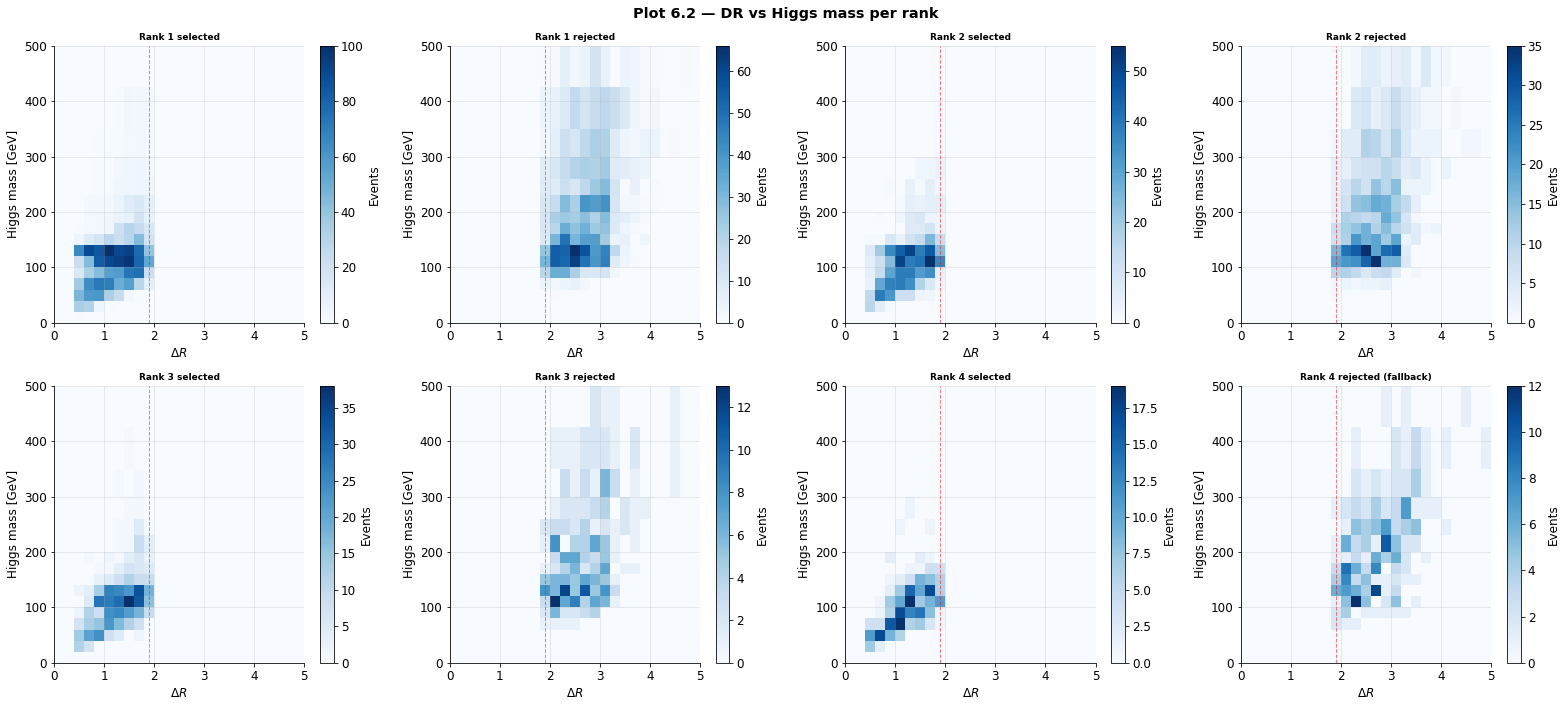

In [23]:
dr_mass_plots = [
    ('dr_vs_mass_rank1_selected', 'Rank 1 selected'),
    ('dr_vs_mass_rank1_rejected', 'Rank 1 rejected'),
    ('dr_vs_mass_rank2_selected', 'Rank 2 selected'),
    ('dr_vs_mass_rank2_rejected', 'Rank 2 rejected'),
    ('dr_vs_mass_rank3_selected', 'Rank 3 selected'),
    ('dr_vs_mass_rank3_rejected', 'Rank 3 rejected'),
    ('dr_vs_mass_rank4_selected', 'Rank 4 selected'),
    ('dr_vs_mass_rank4_rejected', 'Rank 4 rejected (fallback)'),
]
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()
for ax, (var, title) in zip(axes_flat, dr_mass_plots):
    try:
        vals, ex, ey = get_hist2d(out, var)
        im = ax.pcolormesh(ex, ey, vals.T, cmap='Blues')
        plt.colorbar(im, ax=ax, label='Events')
        ax.axvline(1.9, color='red', linestyle='--', alpha=0.5, linewidth=1, label='DR=1.9')
        ax.set_xlabel(r'$\Delta R$')
        ax.set_ylabel('Higgs mass [GeV]')
        ax.set_title(title, fontweight='bold', fontsize=9)
    except Exception as ex_err:
        print(f'  Skipping {var}: {ex_err}')
fig.suptitle('Plot 6.2 — DR vs Higgs mass per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_6_2_dr_vs_mass_per_rank.png', dpi=150)
plt.show()

### Plot 6.3 — Truth vs reco Higgs mass 2D

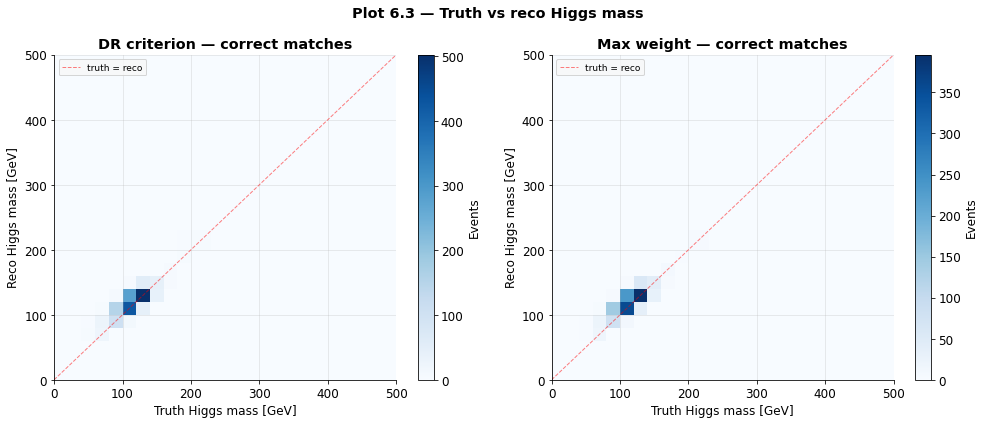

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, var, title in [
    (axes[0], 'truth_vs_reco_higgs_mass_dr',        'DR criterion — correct matches'),
    (axes[1], 'truth_vs_reco_higgs_mass_maxweight',  'Max weight — correct matches'),
]:
    try:
        vals, ex, ey = get_hist2d(out, var)
        im = ax.pcolormesh(ex, ey, vals.T, cmap='Blues')
        plt.colorbar(im, ax=ax, label='Events')
        ax.plot([0, 500], [0, 500], 'r--', alpha=0.5, linewidth=1, label='truth = reco')
        ax.set_xlabel('Truth Higgs mass [GeV]')
        ax.set_ylabel('Reco Higgs mass [GeV]')
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=9)
    except Exception as ex_err:
        print(f'  Skipping {var}: {ex_err}')
fig.suptitle('Plot 6.3 — Truth vs reco Higgs mass', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_6_3_truth_vs_reco_mass.png', dpi=150)
plt.show()

## Summary

In [ ]:
vals2d, ex, ey = get_hist2d(out, 'rank_vs_correct_match')

# rank_used bins: [-1,0,1,2,3,4,5] → no_reco, fallback, rank1, rank2, rank3, rank4
# correct_match bins: [0,1,2,3] → no_reco_solution, neither, both_correct, empty
rank_labels  = ['fallback', 'rank 1', 'rank 2', 'rank 3', 'rank 4']
rank_indices = [1, 2, 3, 4, 5]  # skip bin 0 (no reco = None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: stacked bar — neither correct vs both correct per rank
ax = axes[0]
bottom = np.zeros(len(rank_indices))
match_labels  = ['neither correct', 'both correct']
match_indices = [1, 2]
match_colors  = [COLORS['rank3'], COLORS['rank1']]

for midx, mlabel, mcolor in zip(match_indices, match_labels, match_colors):
    counts = np.array([vals2d[ridx, midx] for ridx in rank_indices])
    ax.bar(range(len(rank_indices)), counts, bottom=bottom,
           color=mcolor, label=mlabel, edgecolor='white', linewidth=0.5)
    bottom += counts
ax.set_xticks(range(len(rank_indices)))
ax.set_xticklabels(rank_labels)
ax.set_ylabel('Events')
ax.legend(fontsize=9)
ax.set_title('Match categories per selected rank', fontweight='bold')

# Plot 2: efficiency per rank
ax = axes[1]
effs = []
for ridx in rank_indices:
    total   = vals2d[ridx, 1] + vals2d[ridx, 2]  # neither + both correct
    correct = vals2d[ridx, 2]                      # both correct
    effs.append(correct / max(1, total))

colors = ['#888888', COLORS['rank1'], COLORS['rank2'], COLORS['rank3'], COLORS['rank4']]
bars = ax.bar(range(len(rank_indices)), effs, color=colors, edgecolor='white', linewidth=1.5)
for bar, eff, ridx in zip(bars, effs, rank_indices):
    n_correct = int(vals2d[ridx, 2])
    n_total   = int(vals2d[ridx, 1] + vals2d[ridx, 2])
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{eff:.3f}\n({n_correct}/{n_total})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(rank_indices)))
ax.set_xticklabels(rank_labels)
ax.set_ylabel('Efficiency (correct_match == 2)')
ax.set_ylim(0, max(effs) * 1.5)
ax.set_title('Mass reco efficiency per selected rank', fontweight='bold')

fig.suptitle('Rank vs correct match — efficiency breakdown', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_rank_vs_correct_match.png', dpi=150)
plt.show()

# Print summary
print('\nEfficiency per rank:')
for label, ridx, eff in zip(rank_labels, rank_indices, effs):
    n_correct = int(vals2d[ridx, 2])
    n_total   = int(vals2d[ridx, 1] + vals2d[ridx, 2])
    print(f'  {label:12s}: {eff:.3f}  ({n_correct}/{n_total})')

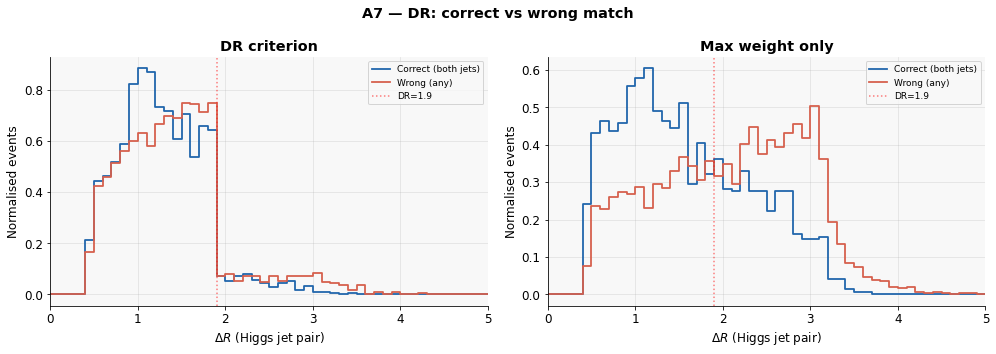

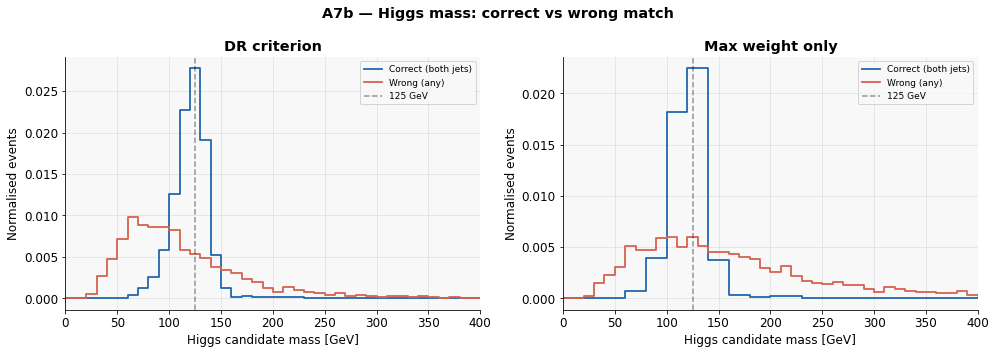

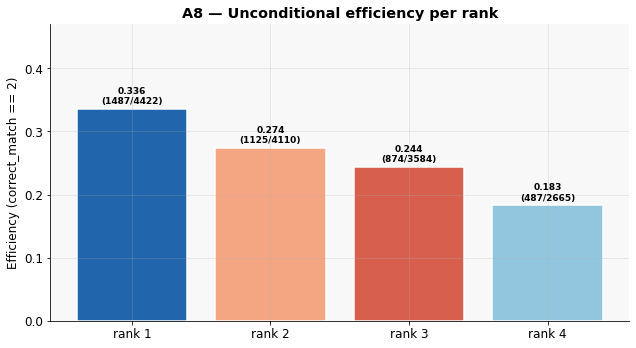


Unconditional efficiency per rank:
  rank 1: 0.336 (1487/4422)
  rank 2: 0.274 (1125/4110)
  rank 3: 0.244 (874/3584)
  rank 4: 0.183 (487/2665)


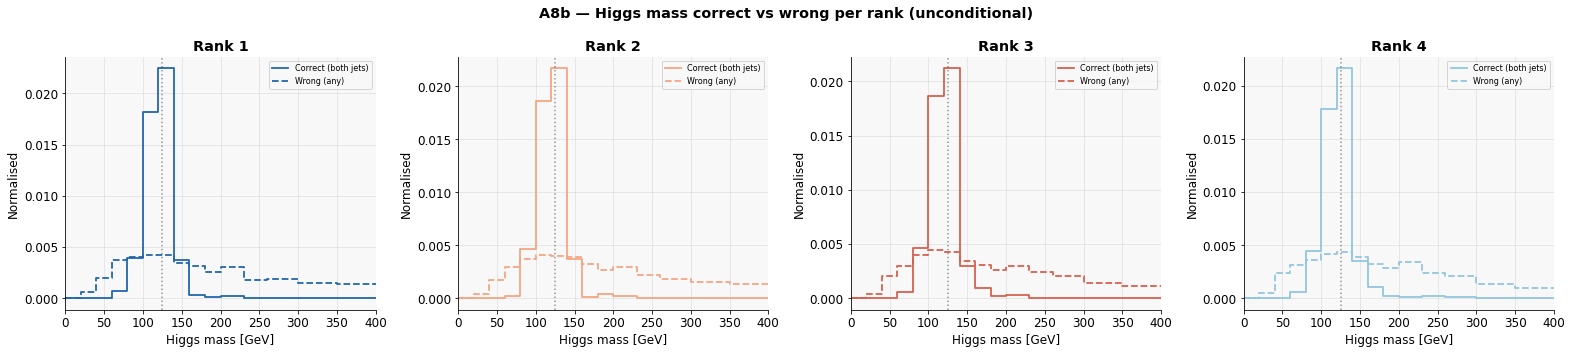

In [29]:
# =====================================================================
# A7 — DR correct vs wrong: DR criterion vs max weight
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pairs, title in [
    (axes[0], [
        ('Massreco_chosen_pair_correct_dr', COLORS['rank1'], 'Correct (both jets)'),
        ('Massreco_chosen_pair_wrong_dr',   COLORS['rank3'], 'Wrong (any)'),
    ], 'DR criterion'),
    (axes[1], [
        ('massreco_maxweight_correct_dr', COLORS['rank1'], 'Correct (both jets)'),
        ('massreco_maxweight_wrong_dr',   COLORS['rank3'], 'Wrong (any)'),
    ], 'Max weight only'),
]:
    for var, color, label in pairs:
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(np.append(e[:-1], e[-1]), np.append(v / max(1, norm), 0),
                    where='post', color=color, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(1.9, color='red', linestyle=':', alpha=0.5, label='DR=1.9')
    ax.set_xlabel(r'$\Delta R$ (Higgs jet pair)')
    ax.set_ylabel('Normalised events')
    ax.set_xlim(0, 5)
    ax.legend(fontsize=9)
    ax.set_title(title, fontweight='bold')

fig.suptitle('A7 — DR: correct vs wrong match', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A7_dr_correct_vs_wrong.png', dpi=150)
plt.show()

# =====================================================================
# A7b — Higgs mass correct vs wrong: DR criterion vs max weight
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pairs, title in [
    (axes[0], [
        ('Massreco_chosen_pair_correct_higgs_mass', COLORS['rank1'], 'Correct (both jets)'),
        ('Massreco_chosen_pair_wrong_higgs_mass',   COLORS['rank3'], 'Wrong (any)'),
    ], 'DR criterion'),
    (axes[1], [
        ('Massreco_maxweight_correct_higgs_mass',  COLORS['rank1'], 'Correct (both jets)'),
        ('massreco_maxweight_wrong_higgs_mass',     COLORS['rank3'], 'Wrong (any)'),
    ], 'Max weight only'),
]:
    for var, color, label in pairs:
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(np.append(e[:-1], e[-1]), np.append(v / max(1, norm), 0),
                    where='post', color=color, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
    ax.set_xlabel('Higgs candidate mass [GeV]')
    ax.set_ylabel('Normalised events')
    ax.set_xlim(0, 400)
    ax.legend(fontsize=9)
    ax.set_title(title, fontweight='bold')

fig.suptitle('A7b — Higgs mass: correct vs wrong match', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A7b_mass_correct_vs_wrong.png', dpi=150)
plt.show()

# =====================================================================
# A8 — Unconditional efficiency per rank
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 5))

rank_labels  = ['rank 1', 'rank 2', 'rank 3', 'rank 4']
rank_vars    = ['correct_match_rank1', 'correct_match_rank2',
                'correct_match_rank3', 'correct_match_rank4']
rank_colors  = [COLORS['rank1'], COLORS['rank2'], COLORS['rank3'], COLORS['rank4']]

effs = []
for var in rank_vars:
    try:
        v, e = get_hist(out, var)
        # bins: 0=no_reco/skipped, 1=neither, 2=both_correct, 3=empty
        total   = v[1] + v[2]
        correct = v[2]
        effs.append((correct / max(1, total), int(correct), int(total)))
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
        effs.append((0, 0, 0))

bars = ax.bar(range(len(rank_labels)), [e[0] for e in effs],
              color=rank_colors, edgecolor='white', linewidth=1.5)
for bar, (eff, n_correct, n_total) in zip(bars, effs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{eff:.3f}\n({n_correct}/{n_total})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(rank_labels)))
ax.set_xticklabels(rank_labels)
ax.set_ylabel('Efficiency (correct_match == 2)')
ax.set_ylim(0, max(e[0] for e in effs) * 1.4)
ax.set_title('A8 — Unconditional efficiency per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A8_unconditional_efficiency.png', dpi=150)
plt.show()

print('\nUnconditional efficiency per rank:')
for label, (eff, n_correct, n_total) in zip(rank_labels, effs):
    print(f'  {label}: {eff:.3f} ({n_correct}/{n_total})')

# =====================================================================
# A8b — Higgs mass correct vs wrong per rank (4-panel)
# =====================================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, rank_num, color in zip(axes, [1,2,3,4],
                                [COLORS['rank1'], COLORS['rank2'],
                                 COLORS['rank3'], COLORS['rank4']]):
    for var, ls, label in [
        (f'higgs_mass_rank{rank_num}_correct', '-',  'Correct (both jets)'),
        (f'higgs_mass_rank{rank_num}_wrong',   '--', 'Wrong (any)'),
    ]:
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(np.append(e[:-1], e[-1]), np.append(v / max(1, norm), 0),
                    where='post', color=color, linestyle=ls, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(125, color='black', linestyle=':', alpha=0.4)
    ax.set_xlabel('Higgs mass [GeV]')
    ax.set_ylabel('Normalised')
    ax.set_xlim(0, 400)
    ax.legend(fontsize=8)
    ax.set_title(f'Rank {rank_num}', fontweight='bold')

fig.suptitle('A8b — Higgs mass correct vs wrong per rank (unconditional)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A8b_mass_correct_wrong_per_rank.png', dpi=150)
plt.show()

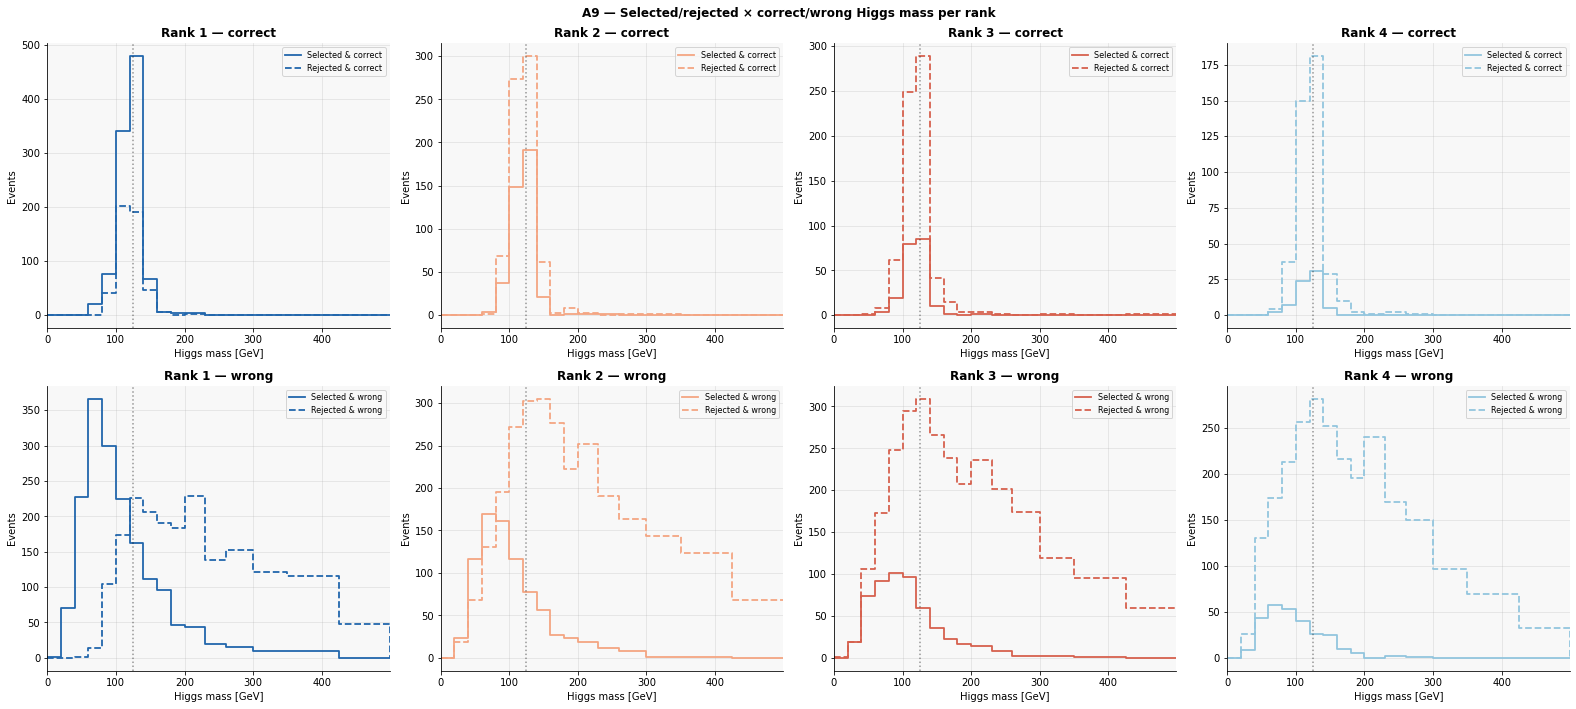

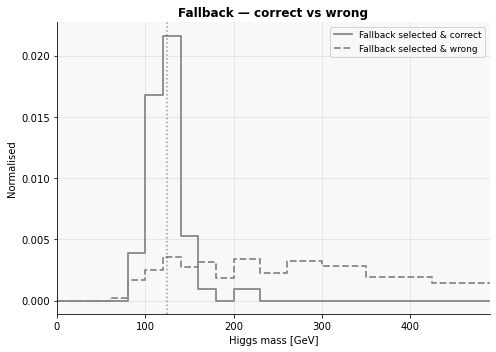

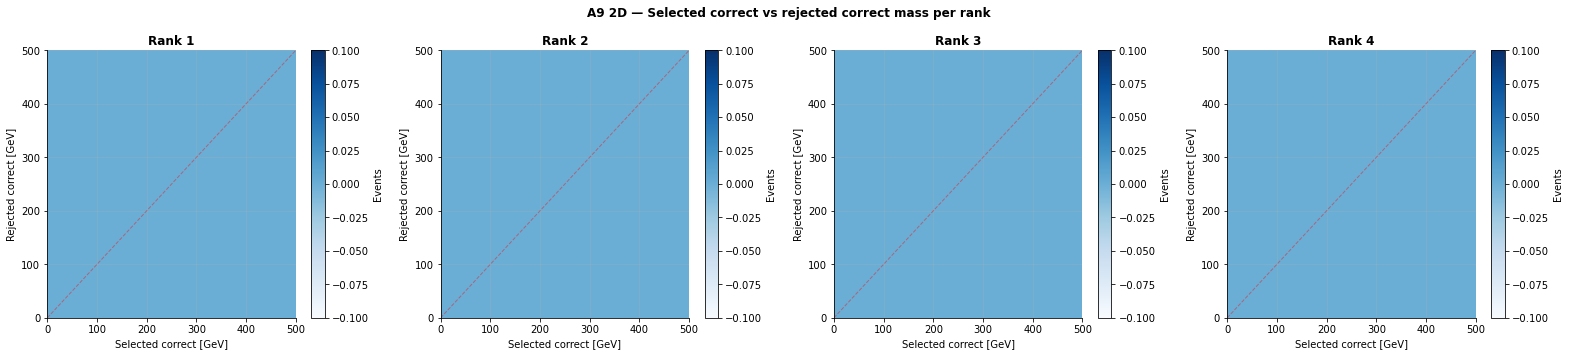

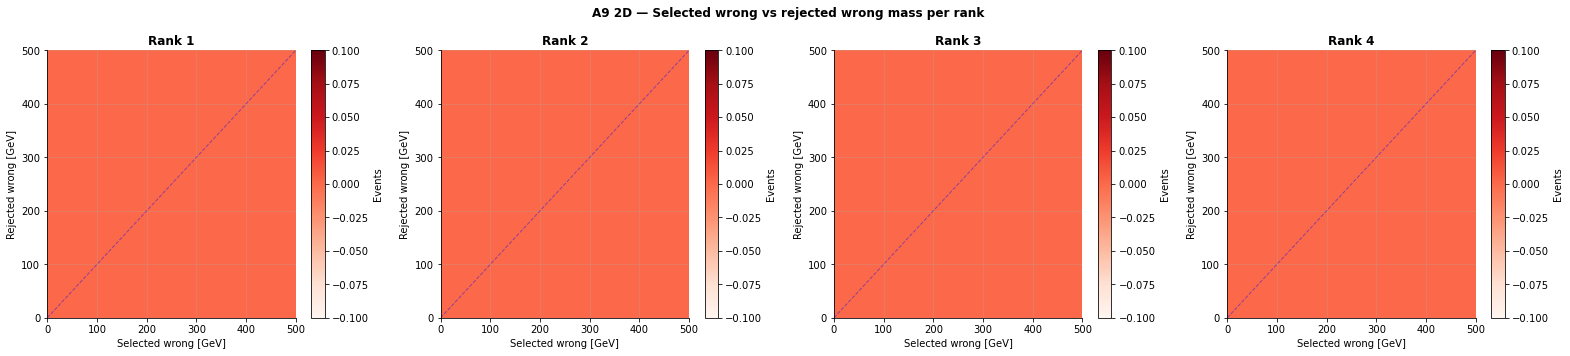


A9 — Selected/rejected × correct/wrong per rank:
Rank        Sel.Correct  Sel.Wrong  Rej.Correct  Rej.Wrong
--------------------------------------------------------
Rank 1           997 (19.6%)    1705 (33.5%)     489 (9.6%)    1904 (37.4%)
Rank 2           404 (8.7%)     809 (17.3%)     721 (15.5%)    2729 (58.5%)
Rank 3           198 (4.8%)     544 (13.1%)     676 (16.2%)    2749 (66.0%)
Rank 4            69 (2.1%)     272 (8.3%)     417 (12.8%)    2505 (76.8%)
Fallback        103 (20.9%)     390 (79.1%)                 N/A


In [4]:
# =====================================================================
# A9 — Selected/rejected × correct/wrong per rank (4-panel grid)
# =====================================================================
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
rank_colors = [COLORS['rank1'], COLORS['rank2'], COLORS['rank3'], COLORS['rank4']]

for col, (r, color) in enumerate(zip([1,2,3,4], rank_colors)):
    # Top row: selected correct vs rejected correct
    ax = axes[0][col]
    for var, ls, label in [
        (f'higgs_mass_rank{r}_selected_correct', '-',  'Selected & correct'),
        (f'higgs_mass_rank{r}_rejected_correct', '--', 'Rejected & correct'),
    ]:
        try:
            v, e = get_hist(out_mc, var)
            norm = integral(v, e)
            if norm > 0:
                ax.step(np.append(e[:-1], e[-1]), np.append(v , 0),
                        where='post', color=color, linestyle=ls, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(125, color='black', linestyle=':', alpha=0.4)
    ax.set_xlabel('Higgs mass [GeV]')
    ax.set_ylabel('Events')
    ax.set_xlim(0, 499)
    ax.legend(fontsize=8)
    ax.set_title(f'Rank {r} — correct', fontweight='bold')

    # Bottom row: selected wrong vs rejected wrong
    ax = axes[1][col]
    for var, ls, label in [
        (f'higgs_mass_rank{r}_selected_wrong', '-',  'Selected & wrong'),
        (f'higgs_mass_rank{r}_rejected_wrong', '--', 'Rejected & wrong'),
    ]:
        try:
            v, e = get_hist(out_mc, var)
            norm = integral(v, e)
            if norm > 0:
                ax.step(np.append(e[:-1], e[-1]), np.append(v , 0),
                        where='post', color=color, linestyle=ls, label=label, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(125, color='black', linestyle=':', alpha=0.4)
    ax.set_xlabel('Higgs mass [GeV]')
    ax.set_ylabel('Events')
    ax.set_xlim(0, 499)
    ax.legend(fontsize=8)
    ax.set_title(f'Rank {r} — wrong', fontweight='bold')

fig.suptitle('A9 — Selected/rejected × correct/wrong Higgs mass per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A9_selected_rejected_correct_wrong.png', dpi=150)
plt.show()

# =====================================================================
# A9 — Fallback selected correct vs wrong
# =====================================================================
fig, ax = plt.subplots(figsize=(7, 5))
for var, color, ls, label in [
    ('higgs_mass_fallback_selected_correct', '#888888', '-',  'Fallback selected & correct'),
    ('higgs_mass_fallback_selected_wrong',   '#888888', '--', 'Fallback selected & wrong'),
]:
    try:
        v, e = get_hist(out_mc, var)
        norm = integral(v, e)
        if norm > 0:
            ax.step(np.append(e[:-1], e[-1]), np.append(v / norm, 0),
                    where='post', color=color, linestyle=ls, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle=':', alpha=0.4)
ax.set_xlabel('Higgs mass [GeV]')
ax.set_ylabel('Normalised')
ax.set_xlim(0, 490)
ax.legend(fontsize=9)
ax.set_title('Fallback — correct vs wrong', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A9_fallback.png', dpi=150)
plt.show()

# =====================================================================
# A9 — 2D: selected correct vs rejected correct per rank
# =====================================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, r in zip(axes, [1,2,3,4]):
    try:
        vals, ex, ey = get_hist2d(out_mc, f'rank{r}_selected_correct_vs_rejected_correct')
        im = ax.pcolormesh(ex, ey, vals.T, cmap='Blues')
        plt.colorbar(im, ax=ax, label='Events')
        ax.plot([0,500],[0,500],'r--', alpha=0.4, linewidth=1)
        ax.set_xlabel('Selected correct [GeV]')
        ax.set_ylabel('Rejected correct [GeV]')
        ax.set_title(f'Rank {r}', fontweight='bold')
    except Exception as ex_err:
        print(f'  Skipping rank{r}: {ex_err}')
fig.suptitle('A9 2D — Selected correct vs rejected correct mass per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A9_2d_correct.png', dpi=150)
plt.show()

# =====================================================================
# A9 — 2D: selected wrong vs rejected wrong per rank
# =====================================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, r in zip(axes, [1,2,3,4]):
    try:
        vals, ex, ey = get_hist2d(out_mc, f'rank{r}_selected_wrong_vs_rejected_wrong')
        im = ax.pcolormesh(ex, ey, vals.T, cmap='Reds')
        plt.colorbar(im, ax=ax, label='Events')
        ax.plot([0,500],[0,500],'b--', alpha=0.4, linewidth=1)
        ax.set_xlabel('Selected wrong [GeV]')
        ax.set_ylabel('Rejected wrong [GeV]')
        ax.set_title(f'Rank {r}', fontweight='bold')
    except Exception as ex_err:
        print(f'  Skipping rank{r}: {ex_err}')
fig.suptitle('A9 2D — Selected wrong vs rejected wrong mass per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A9_2d_wrong.png', dpi=150)
plt.show()

# Print percentages for A9
print('\nA9 — Selected/rejected × correct/wrong per rank:')
print(f'{"Rank":<10} {"Sel.Correct":>12} {"Sel.Wrong":>10} {"Rej.Correct":>12} {"Rej.Wrong":>10}')
print('-' * 56)

for r in [1, 2, 3, 4]:
    counts = {}
    for case in ['selected_correct', 'selected_wrong', 'rejected_correct', 'rejected_wrong']:
        try:
            v, e = get_hist(out_mc, f'higgs_mass_rank{r}_{case}')
            counts[case] = int(v.sum())
        except:
            counts[case] = 0
    total = sum(counts.values())
    print(f"Rank {r:<6} "
          f"{counts['selected_correct']:>8} ({100*counts['selected_correct']/max(1,total):.1f}%)"
          f"{counts['selected_wrong']:>8} ({100*counts['selected_wrong']/max(1,total):.1f}%)"
          f"{counts['rejected_correct']:>8} ({100*counts['rejected_correct']/max(1,total):.1f}%)"
          f"{counts['rejected_wrong']:>8} ({100*counts['rejected_wrong']/max(1,total):.1f}%)")

# Fallback
counts = {}
for case in ['selected_correct', 'selected_wrong']:
    try:
        v, e = get_hist(out_mc, f'higgs_mass_fallback_{case}')
        counts[case] = int(v.sum())
    except:
        counts[case] = 0
total = sum(counts.values())
print(f"Fallback   "
      f"{counts['selected_correct']:>8} ({100*counts['selected_correct']/max(1,total):.1f}%)"
      f"{counts['selected_wrong']:>8} ({100*counts['selected_wrong']/max(1,total):.1f}%)"
      f"{'N/A':>20}")

In [8]:
print('\nA9 — Selected/rejected × correct/wrong per rank:')
print(f'  Denominator: total truth-matched events')
print()
print(f'{"":10} {"Sel.Correct":>14} {"Sel.Wrong":>14} {"Rej.Correct":>14} {"Rej.Wrong":>14} {"Total":>10}')
print('─' * 80)

v_total, _ = get_hist(out_mc, 'correct_match_dr')
total_events = int(v_total.sum())
print(f'  Total truth-matched events: {total_events}')
print()

for r, label in [(1,'Rank 1'), (2,'Rank 2'), (3,'Rank 3'), (4,'Rank 4')]:
    counts = {}
    for case in ['selected_correct', 'selected_wrong', 'rejected_correct', 'rejected_wrong']:
        try:
            v, e = get_hist(out_mc, f'higgs_mass_rank{r}_{case}')
            counts[case] = int(v.sum())
        except:
            counts[case] = 0
    sc = counts['selected_correct']
    sw = counts['selected_wrong']
    rc = counts['rejected_correct']
    rw = counts['rejected_wrong']
    row_total = sc + sw + rc + rw
    print(f'{label:<10} '
          f'{sc:>6} ({100*sc/max(1,total_events):4.1f}%)  '
          f'{sw:>6} ({100*sw/max(1,total_events):4.1f}%)  '
          f'{rc:>6} ({100*rc/max(1,total_events):4.1f}%)  '
          f'{rw:>6} ({100*rw/max(1,total_events):4.1f}%)  '
          f'{row_total:>6} ({100*row_total/max(1,total_events):4.1f}%)')

print('─' * 80)

# Fallback — denominator is fallback events only (rank_used == 0)
counts = {}
for case in ['selected_correct', 'selected_wrong']:
    try:
        v, e = get_hist(out_mc, f'higgs_mass_fallback_{case}')
        counts[case] = int(v.sum())
    except:
        counts[case] = 0
fb_total = counts['selected_correct'] + counts['selected_wrong']
sc = counts['selected_correct']
sw = counts['selected_wrong']
print(f'{"Fallback":<10} '
      f'{sc:>6} ({100*sc/max(1,fb_total):4.1f}%)  '
      f'{sw:>6} ({100*sw/max(1,fb_total):4.1f}%)  '
      f'{"N/A":>14}  {"N/A":>14}  '
      f'{fb_total:>6} ({100*fb_total/max(1,total_events):4.1f}%)')
print(f'  Note: fallback percentages are over fallback events ({fb_total}), '
      f'total column is over all truth-matched events ({total_events})')


A9 — Selected/rejected × correct/wrong per rank:
  Denominator: total truth-matched events

              Sel.Correct      Sel.Wrong    Rej.Correct      Rej.Wrong      Total
────────────────────────────────────────────────────────────────────────────────
  Total truth-matched events: 4993

Rank 1        997 (20.0%)    1705 (34.1%)     489 ( 9.8%)    1904 (38.1%)    5095 (102.0%)
Rank 2        404 ( 8.1%)     809 (16.2%)     721 (14.4%)    2729 (54.7%)    4663 (93.4%)
Rank 3        198 ( 4.0%)     544 (10.9%)     676 (13.5%)    2749 (55.1%)    4167 (83.5%)
Rank 4         69 ( 1.4%)     272 ( 5.4%)     417 ( 8.4%)    2505 (50.2%)    3263 (65.4%)
────────────────────────────────────────────────────────────────────────────────
Fallback      103 (20.9%)     390 (79.1%)             N/A             N/A     493 ( 9.9%)
  Note: fallback percentages are over fallback events (493), total column is over all truth-matched events (4993)


In [10]:
# Get total truth-matched events from correct_match_dr
v_cm, _ = get_hist(out_mc, 'correct_match_dr')
total_events      = int(v_cm.sum())
total_sel_correct = int(v_cm[2])  # correct_match == 2
total_sel_wrong   = int(v_cm[1])  # correct_match == 1 (neither/partial)
total_no_reco     = int(v_cm[0])  # no reco solution

print('\n--- Overall per rank (unconditional correct vs wrong) ---')
print(f'  Denominator: {total_events} truth-matched events')
print()
print(f'{"":10} {"Correct":>16} {"Wrong":>16} {"Efficiency":>12}')
print('─' * 58)
for r, label in [(1,'Rank 1'), (2,'Rank 2'), (3,'Rank 3'), (4,'Rank 4')]:
    try:
        vc, _ = get_hist(out_mc, f'higgs_mass_rank{r}_correct')
        vw, _ = get_hist(out_mc, f'higgs_mass_rank{r}_wrong')
        nc = int(vc.sum())
        nw = int(vw.sum())
        nt = nc + nw
        print(f'{label:<10} '
              f'{nc:>6} ({100*nc/max(1,total_events):4.1f}%)  '
              f'{nw:>6} ({100*nw/max(1,total_events):4.1f}%)  '
              f'{100*nc/max(1,nt):5.1f}%')
    except Exception as ex:
        print(f'  Skipping rank {r}: {ex}')

print()
print('--- Overall DR selection: correct vs wrong ---')
print(f'  Denominator: {total_events} truth-matched events')
print()
print(f'  Selected correct : {total_sel_correct:>6} ({100*total_sel_correct/max(1,total_events):4.1f}%)')
print(f'  Selected wrong   : {total_sel_wrong:>6} ({100*total_sel_wrong/max(1,total_events):4.1f}%)')
print(f'  No reco solution : {total_no_reco:>6} ({100*total_no_reco/max(1,total_events):4.1f}%)')
print(f'  Overall efficiency (correct / correct+wrong): '
      f'{100*total_sel_correct/max(1,total_sel_correct+total_sel_wrong):.1f}%')


--- Overall per rank (unconditional correct vs wrong) ---
  Denominator: 4993 truth-matched events

                    Correct            Wrong   Efficiency
──────────────────────────────────────────────────────────
Rank 1       1486 (29.8%)    3313 (66.4%)   31.0%
Rank 2       1125 (22.5%)    3413 (68.4%)   24.8%
Rank 3        874 (17.5%)    3215 (64.4%)   21.4%
Rank 4        486 ( 9.7%)    2733 (54.7%)   15.1%

--- Overall DR selection: correct vs wrong ---
  Denominator: 4993 truth-matched events

  Selected correct :   1772 (35.5%)
  Selected wrong   :   2750 (55.1%)
  No reco solution :    471 ( 9.4%)
  Overall efficiency (correct / correct+wrong): 39.2%


In [25]:
v_cm, _ = get_hist(out_mc, 'correct_match_dr')
print('correct_match_dr bins:')
print(f'  bin 0 (no reco solution) : {int(v_cm[0])}')
print(f'  bin 1 (neither correct)  : {int(v_cm[1])}')
print(f'  bin 2 (both correct)     : {int(v_cm[2])}')
print(f'  total in histogram       : {int(v_cm.sum())}')

# Get total events from rank_used (all events with reco solution, no truth filter)
v_rank, _ = get_hist(out_mc, 'rank_used')
total_with_reco = int(v_rank[1:].sum())  # skip no-reco bin
print(f'\n  total events with reco solution (rank_used): {total_with_reco}')
print(f'  truth-matched events (correct_match_dr):     {int(v_cm.sum())}')
print(f'  not truth-matched:                           {total_with_reco - int(v_cm.sum())}')
print(f'  fraction not truth-matched:                  {100*(total_with_reco - int(v_cm.sum()))/max(1,total_with_reco):.1f}%')

correct_match_dr bins:
  bin 0 (no reco solution) : 471
  bin 1 (neither correct)  : 2750
  bin 2 (both correct)     : 1772
  total in histogram       : 4993

  total events with reco solution (rank_used): 5545
  truth-matched events (correct_match_dr):     4993
  not truth-matched:                           552
  fraction not truth-matched:                  10.0%


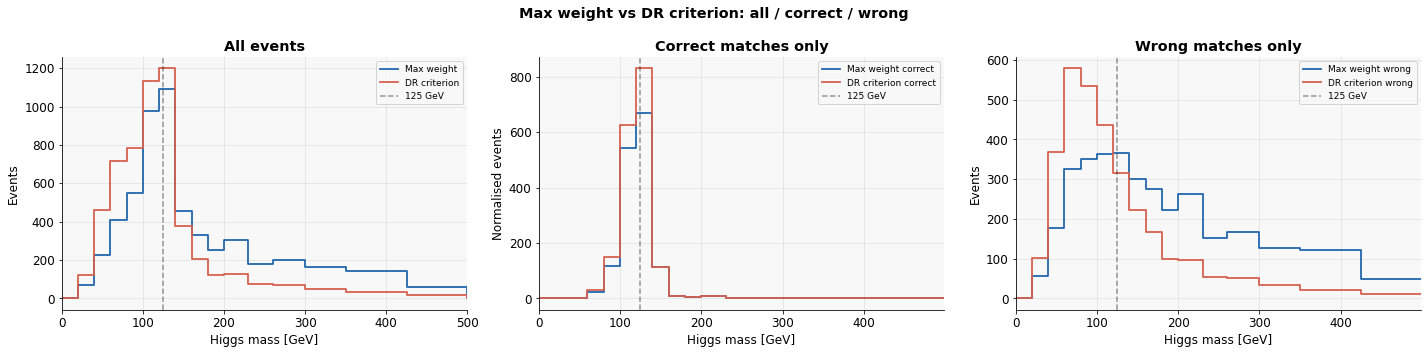


--- Max weight vs DR criterion summary ---

All events:
  Max weight total      : 5414
  DR criterion total    : 5491

Truth-matched events   : 4993
  No reco solution     : 471 (9.4%)

                            Max weight   DR criterion    Delta
──────────────────────────────────────────────────────────────
Correct (both jets)           1487 (29.8%)      1772 (35.5%)    +285
Wrong (any)                   2935 (58.8%)      2750 (55.1%)    -185
──────────────────────────────────────────────────────────────
Efficiency                      0.336         0.392   +0.056


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: All events — max weight vs DR criterion
ax = axes[0]
for var, color, label in [
    ('Max_Weight_Higgs_Mass',             COLORS['maxweight'], 'Max weight'),
    ('Massreco_chosen_pair_higgs_mass_4', COLORS['dr'],        'DR criterion'),
]:
    v, e = get_hist(out_mc, var)
    norm = integral(v, e)
    ax.step(np.append(e[:-1], e[-1]), np.append(v , 0),
            where='post', color=color, label=label, linewidth=1.8)
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs mass [GeV]')
ax.set_ylabel('Events')
ax.set_xlim(0, 500)
ax.legend(fontsize=9)
ax.set_title('All events', fontweight='bold')

# Panel 2: Correct matches — max weight vs DR criterion
ax = axes[1]
for var, color, label in [
    ('higgs_mass_rank1_correct',               COLORS['maxweight'], 'Max weight correct'),
    ('Massreco_chosen_pair_correct_higgs_mass', COLORS['dr'],        'DR criterion correct'),
]:
    try:
        v, e = get_hist(out_mc, var)
        norm = integral(v, e)
        ax.step(np.append(e[:-1], e[-1]), np.append(v , 0),
                where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 499)
ax.legend(fontsize=9)
ax.set_title('Correct matches only', fontweight='bold')

# Panel 3: Wrong matches — max weight vs DR criterion
ax = axes[2]
for var, color, label in [
    ('massreco_maxweight_wrong_higgs_mass',    COLORS['maxweight'], 'Max weight wrong'),
    ('Massreco_chosen_pair_wrong_higgs_mass',  COLORS['dr'],        'DR criterion wrong'),
]:
    try:
        v, e = get_hist(out_mc, var)
        norm = integral(v, e)
        ax.step(np.append(e[:-1], e[-1]), np.append(v, 0),
                where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs mass [GeV]')
ax.set_ylabel('Events')
ax.set_xlim(0, 499)
ax.legend(fontsize=9)
ax.set_title('Wrong matches only', fontweight='bold')

plt.suptitle('Max weight vs DR criterion: all / correct / wrong', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_mw_vs_dr_all_correct_wrong.png', dpi=150)
plt.show()
# Print summary numbers
print('\n--- Max weight vs DR criterion summary ---')

# All events
v_mw, e_mw = get_hist(out_mc, 'Max_Weight_Higgs_Mass')
v_dr, e_dr = get_hist(out_mc, 'Massreco_chosen_pair_higgs_mass_4')
print(f'\nAll events:')
print(f'  Max weight total      : {int(v_mw.sum())}')
print(f'  DR criterion total    : {int(v_dr.sum())}')

# Correct
v_mw_c, _ = get_hist(out_mc, 'higgs_mass_rank1_correct')
v_dr_c, _ = get_hist(out_mc, 'Massreco_chosen_pair_correct_higgs_mass')
n_mw_c = int(v_mw_c.sum())
n_dr_c = int(v_dr_c.sum())

# Wrong
v_mw_w, _ = get_hist(out_mc, 'massreco_maxweight_wrong_higgs_mass')
v_dr_w, _ = get_hist(out_mc, 'Massreco_chosen_pair_wrong_higgs_mass')
n_mw_w = int(v_mw_w.sum())
n_dr_w = int(v_dr_w.sum())

# From correct_match histograms
v_cm_mw, _ = get_hist(out_mc, 'correct_match_maxweight')
v_cm_dr, _ = get_hist(out_mc, 'correct_match_dr')
total = int(v_cm_dr.sum())

n_mw_correct = int(v_cm_mw[2])
n_mw_wrong   = int(v_cm_mw[1])
n_dr_correct = int(v_cm_dr[2])
n_dr_wrong   = int(v_cm_dr[1])
n_no_reco    = int(v_cm_dr[0])

print(f'\nTruth-matched events   : {total}')
print(f'  No reco solution     : {n_no_reco} ({100*n_no_reco/max(1,total):.1f}%)')
print(f'\n{"":25} {"Max weight":>12} {"DR criterion":>14} {"Delta":>8}')
print('─' * 62)
print(f'{"Correct (both jets)":<25} '
      f'{n_mw_correct:>8} ({100*n_mw_correct/max(1,total):4.1f}%)  '
      f'{n_dr_correct:>8} ({100*n_dr_correct/max(1,total):4.1f}%)  '
      f'{n_dr_correct-n_mw_correct:>+6}')
print(f'{"Wrong (any)":<25} '
      f'{n_mw_wrong:>8} ({100*n_mw_wrong/max(1,total):4.1f}%)  '
      f'{n_dr_wrong:>8} ({100*n_dr_wrong/max(1,total):4.1f}%)  '
      f'{n_dr_wrong-n_mw_wrong:>+6}')
print('─' * 62)
eff_mw = n_mw_correct / max(1, n_mw_correct + n_mw_wrong)
eff_dr = n_dr_correct / max(1, n_dr_correct + n_dr_wrong)
print(f'{"Efficiency":<25} '
      f'{eff_mw:>11.3f}   '
      f'{eff_dr:>11.3f}   '
      f'{eff_dr-eff_mw:>+.3f}')

In [27]:
print('All plots saved:')
import glob
for f in sorted(glob.glob('plot_*.png')):
    print(' ', f)

All plots saved:
  plot_1_1_rank_used.png
  plot_2_1_higgs_mass_per_rank.png
  plot_2_2_dr_per_rank.png
  plot_3_1_correct_match_comparison.png
  plot_3_2_promotion_breakdown.png
  plot_3_3_correct_vs_wrong_mass.png
  plot_3_3b_all_categories_mass.png
  plot_4_1_overall_mass_comparison.png
  plot_4_2_correct_wrong_mass.png
  plot_4_3_efficiency_comparison.png
  plot_5_1_higgs_mass_selected_per_rank.png
  plot_5_2_higgs_mass_rejected_per_rank.png
  plot_5_3_dr_selected_vs_rejected.png
  plot_6_1_mass_vs_mass_transitions.png
  plot_6_2_dr_vs_mass_per_rank.png
  plot_6_3_truth_vs_reco_mass.png
  plot_A6_selected_vs_rejected_mass.png
  plot_A7_dr_correct_vs_wrong.png
  plot_A7b_mass_correct_vs_wrong.png
  plot_A8_unconditional_efficiency.png
  plot_A8b_mass_correct_wrong_per_rank.png
  plot_rank_vs_correct_match.png
